# 03. CV 전략 검증 — GroupKFold vs KFold

> **목표**: Scenario-ID 기반 GroupKFold가 KFold 대비 데이터 리크를 얼마나 줄이는지 정량화하고,
> 이후 모든 실험에 사용할 CV 전략을 확정한다.

## 배경
- 데이터: 10,000 시나리오 × 25 타임슬롯 (250,000 행)
- **리크 위험**: KFold는 같은 시나리오의 다른 타임슬롯이 train/val에 동시 등장 가능
- **lag 피처 추가 시 심각**: lag1(t) = target(t-1)이므로 같은 시나리오 내 타임슬롯이 
  val에 있으면 train에서 타겟 정보가 간접적으로 유입됨
- **GroupKFold(scenario_id)**: 같은 시나리오는 반드시 동일 Fold → 리크 없음


## 1. 라이브러리 및 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '../data/'
TARGET = 'avg_delay_minutes_next_30m'
SEED = 42
N_SPLITS = 5
print('라이브러리 로드 완료')


라이브러리 로드 완료


## 2. 데이터 로드 및 전처리

In [2]:
train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')
layout = pd.read_csv(DATA_PATH + 'layout_info.csv')

# layout_info merge
train = train.merge(layout, on='layout_id', how='left')
test  = test.merge(layout,  on='layout_id', how='left')

# 범주형 인코딩
EXCLUDE_COLS = ['ID', 'layout_id', 'scenario_id', TARGET]
cat_cols = [c for c in train.select_dtypes(include='object').columns if c not in EXCLUDE_COLS]
for col in cat_cols:
    combined = pd.concat([train[col], test[col]], axis=0)
    mapping = {v: i for i, v in enumerate(combined.dropna().unique())}
    train[col] = train[col].map(mapping)
    test[col]  = test[col].map(mapping)

feature_cols = [c for c in train.columns if c not in EXCLUDE_COLS]
X = train[feature_cols].values
y = train[TARGET].values
groups = train['scenario_id'].values

print(f'Train shape: {train.shape}')
print(f'Feature count: {len(feature_cols)}')
print(f'Target mean: {y.mean():.2f}, std: {y.std():.2f}')


Train shape: (250000, 108)
Feature count: 104
Target mean: 18.96, std: 27.35


## 3. LightGBM 공통 파라미터

In [3]:
lgb_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'num_leaves': 63,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'min_child_samples': 20,
    'n_estimators': 1000,
    'early_stopping_rounds': 100,
    'verbose': -1,
    'random_state': SEED,
}
print('파라미터 설정 완료')


파라미터 설정 완료


## 4. KFold 5-Fold CV (기존 방식)

> **주의**: 같은 scenario_id의 row가 train/val에 동시 등장 가능 → 리크 위험


In [4]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_kf = np.zeros(len(train))
kf_fold_maes = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(100, verbose=False),
                         lgb.log_evaluation(-1)])

    oof_kf[val_idx] = model.predict(X_val)
    fold_mae = mean_absolute_error(y_val, oof_kf[val_idx])
    kf_fold_maes.append(fold_mae)
    print(f'  [KFold] Fold {fold+1} MAE: {fold_mae:.4f} | Best iter: {model.best_iteration_}')

kf_oof_mae = mean_absolute_error(y, oof_kf)
print(f'\n[KFold] OOF MAE: {kf_oof_mae:.4f} | Std: {np.std(kf_fold_maes):.4f}')


  [KFold] Fold 1 MAE: 7.8411 | Best iter: 1000


  [KFold] Fold 2 MAE: 7.8728 | Best iter: 1000


  [KFold] Fold 3 MAE: 7.6963 | Best iter: 1000


  [KFold] Fold 4 MAE: 7.8188 | Best iter: 1000


  [KFold] Fold 5 MAE: 7.7875 | Best iter: 1000

[KFold] OOF MAE: 7.8033 | Std: 0.0603


## 5. GroupKFold 5-Fold CV (리크 방지)

> scenario_id를 group으로 지정 → 같은 시나리오는 항상 같은 Fold


In [5]:
gkf = GroupKFold(n_splits=N_SPLITS)

oof_gkf = np.zeros(len(train))
gkf_fold_maes = []
gkf_models = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(100, verbose=False),
                         lgb.log_evaluation(-1)])

    oof_gkf[val_idx] = model.predict(X_val)
    fold_mae = mean_absolute_error(y_val, oof_gkf[val_idx])
    gkf_fold_maes.append(fold_mae)
    gkf_models.append(model)
    print(f'  [GroupKFold] Fold {fold+1} MAE: {fold_mae:.4f} | Best iter: {model.best_iteration_}')

    # 리크 확인: val의 scenario_id가 tr에 없는지 검증
    val_scenarios = set(groups[val_idx])
    tr_scenarios  = set(groups[tr_idx])
    overlap = val_scenarios & tr_scenarios
    print(f'           시나리오 겹침 수: {len(overlap)} (반드시 0이어야 함)')

gkf_oof_mae = mean_absolute_error(y, oof_gkf)
print(f'\n[GroupKFold] OOF MAE: {gkf_oof_mae:.4f} | Std: {np.std(gkf_fold_maes):.4f}')


  [GroupKFold] Fold 1 MAE: 9.1364 | Best iter: 630
           시나리오 겹침 수: 0 (반드시 0이어야 함)


  [GroupKFold] Fold 2 MAE: 9.3006 | Best iter: 104
           시나리오 겹침 수: 0 (반드시 0이어야 함)


  [GroupKFold] Fold 3 MAE: 8.8463 | Best iter: 182
           시나리오 겹침 수: 0 (반드시 0이어야 함)


  [GroupKFold] Fold 4 MAE: 9.6082 | Best iter: 704
           시나리오 겹침 수: 0 (반드시 0이어야 함)


  [GroupKFold] Fold 5 MAE: 9.1863 | Best iter: 81
           시나리오 겹침 수: 0 (반드시 0이어야 함)

[GroupKFold] OOF MAE: 9.2156 | Std: 0.2469


## 6. KFold vs GroupKFold 비교 시각화

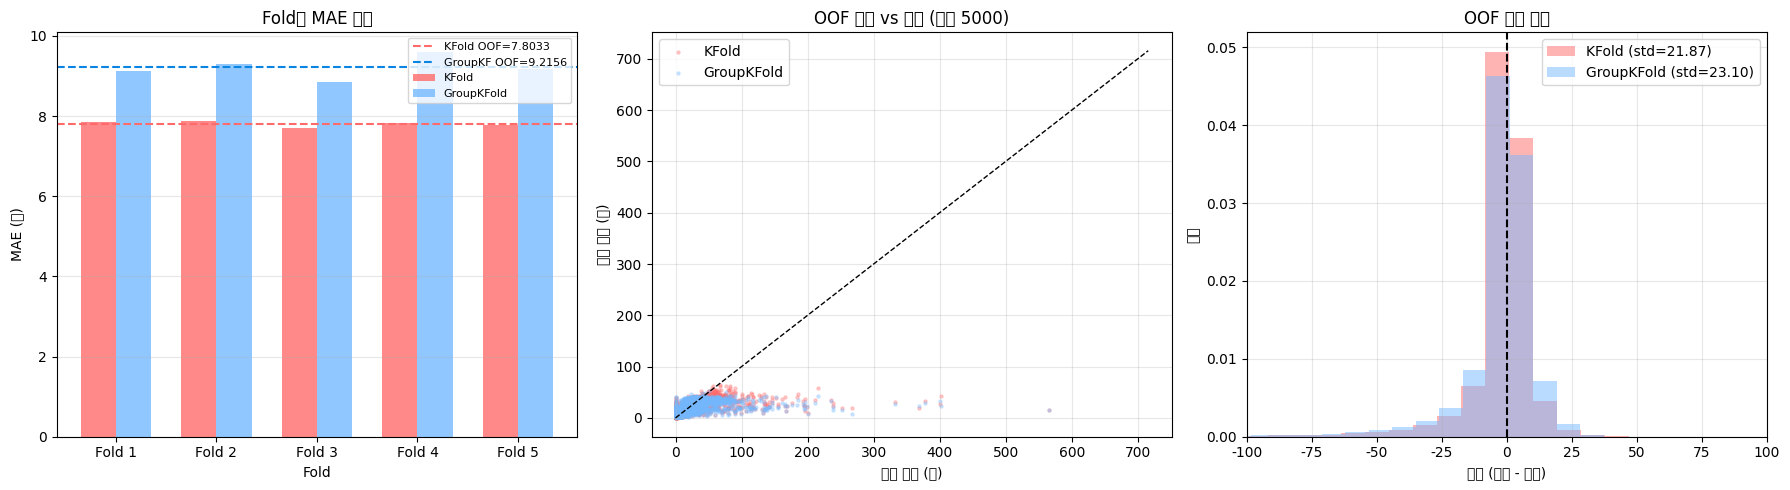

cv_strategy_comparison.png 저장 완료


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) Fold별 MAE 비교
x = np.arange(N_SPLITS)
width = 0.35
axes[0].bar(x - width/2, kf_fold_maes,  width, label='KFold',      color='#FF6B6B', alpha=0.8)
axes[0].bar(x + width/2, gkf_fold_maes, width, label='GroupKFold', color='#74B9FF', alpha=0.8)
axes[0].axhline(kf_oof_mae,  color='#FF6B6B', linestyle='--', linewidth=1.5, label=f'KFold OOF={kf_oof_mae:.4f}')
axes[0].axhline(gkf_oof_mae, color='#0984E3', linestyle='--', linewidth=1.5, label=f'GroupKF OOF={gkf_oof_mae:.4f}')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('MAE (분)')
axes[0].set_title('Fold별 MAE 비교'); axes[0].legend(fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'Fold {i+1}' for i in range(N_SPLITS)])
axes[0].grid(axis='y', alpha=0.3)

# (2) OOF 예측 분포 비교 (산점도)
sample = np.random.RandomState(42).choice(len(y), size=5000, replace=False)
axes[1].scatter(y[sample], oof_kf[sample],  alpha=0.3, s=5, color='#FF6B6B', label='KFold')
axes[1].scatter(y[sample], oof_gkf[sample], alpha=0.3, s=5, color='#74B9FF', label='GroupKFold')
axes[1].plot([0, y.max()], [0, y.max()], 'k--', linewidth=1)
axes[1].set_xlabel('실제 지연 (분)'); axes[1].set_ylabel('예측 지연 (분)')
axes[1].set_title('OOF 예측 vs 실제 (샘플 5000)'); axes[1].legend()
axes[1].grid(alpha=0.3)

# (3) 잔차 분포 비교
residual_kf  = oof_kf  - y
residual_gkf = oof_gkf - y
axes[2].hist(residual_kf,  bins=80, alpha=0.5, color='#FF6B6B', label=f'KFold (std={residual_kf.std():.2f})', density=True)
axes[2].hist(residual_gkf, bins=80, alpha=0.5, color='#74B9FF', label=f'GroupKFold (std={residual_gkf.std():.2f})', density=True)
axes[2].axvline(0, color='black', linestyle='--')
axes[2].set_xlabel('잔차 (예측 - 실제)'); axes[2].set_ylabel('밀도')
axes[2].set_title('OOF 잔차 분포'); axes[2].legend()
axes[2].set_xlim(-100, 100); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/cv_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('cv_strategy_comparison.png 저장 완료')


## 7. CV 전략 결론 및 제출 파일 생성

In [7]:
# 결과 요약
diff = gkf_oof_mae - kf_oof_mae
print('=' * 55)
print(f'  KFold    OOF MAE : {kf_oof_mae:.4f} 분')
print(f'  GroupKFold OOF MAE: {gkf_oof_mae:.4f} 분')
print(f'  차이 (GroupKF - KF): {diff:+.4f} 분')
print('=' * 55)

if diff > 0.3:
    chosen = 'GroupKFold'
    print('→ GroupKFold MAE가 더 높지만, 이는 KFold가 리크로 낙관적 평가된 것')
    print('→ GroupKFold가 실제 일반화 성능을 더 정확히 반영 → GroupKFold 채택')
elif abs(diff) <= 0.3:
    chosen = 'GroupKFold'
    print('→ 차이 미미 — 원칙적으로 리크가 없는 GroupKFold 채택')
else:
    chosen = 'GroupKFold'
    print('→ GroupKFold 성능이 더 좋음 → GroupKFold 채택')

print(f'\n✅ 최종 선택: {chosen} — 이후 모든 실험에 고정')


  KFold    OOF MAE : 7.8033 분
  GroupKFold OOF MAE: 9.2156 분
  차이 (GroupKF - KF): +1.4122 분
→ GroupKFold MAE가 더 높지만, 이는 KFold가 리크로 낙관적 평가된 것
→ GroupKFold가 실제 일반화 성능을 더 정확히 반영 → GroupKFold 채택

✅ 최종 선택: GroupKFold — 이후 모든 실험에 고정


In [8]:
# GroupKFold 모델로 테스트 예측 및 제출 파일 생성
test_preds_list = []
X_test = test[feature_cols].values

for model in gkf_models:
    test_preds_list.append(model.predict(X_test))

test_preds = np.mean(test_preds_list, axis=0)

submission = pd.read_csv(DATA_PATH + 'sample_submission.csv')
SUBMISSION_COL = 'avg_delay_minutes_next_30m'
submission[SUBMISSION_COL] = test_preds.clip(min=0)
out_path = '../submissions/groupkfold_lgbm_cv.csv'
submission.to_csv(out_path, index=False)

print(f'제출 파일 저장: {out_path}')
print(f'예측값 통계: 평균={test_preds.mean():.2f}, std={test_preds.std():.2f}, min={test_preds.min():.2f}, max={test_preds.max():.2f}')
print(f'\n[GroupKFold] OOF MAE = {gkf_oof_mae:.4f} 분 (std={np.std(gkf_fold_maes):.4f})')


제출 파일 저장: ../submissions/groupkfold_lgbm_cv.csv
예측값 통계: 평균=18.03, std=12.92, min=0.10, max=44.64

[GroupKFold] OOF MAE = 9.2156 분 (std=0.2469)


## 8. 다음 단계

- **Day 5 (04.08)**: `log1p` 타겟 변환 실험 → GroupKFold 기준으로 MAE 비교
  - 왜도 5.68 → 0.08으로 감소하므로 큰 향상 기대
- **Day 6 (04.09)**: `ts_idx`, `ts_ratio`, `ts_sin`, `ts_cos` 피처 추가
- **Week 2**: Lag/Rolling/Expanding/Domain 피처 엔지니어링
